## Gold Comparison & Evaluation (Deliverable 1.3.4)

This notebook performs the final comparison between the baseline model and the three-stage cascade. It evaluates whether the cascade meaningfully improves alert quality by reducing false positives and noisy alerts while preserving useful anomaly sensitivity.

**Purpose:**  
To combine the alert outputs from the Baseline Modeling and Cascade Modeling notebooks, compute evaluation metrics, perform paired statistical testing, and generate the comparative visualizations required for Section C.

**Key Goals:**

- Load baseline and cascade alert outputs.
- Align alerts into comparable time windows for paired evaluation.
- Compute alert-volume metrics, false-positive rates, normal-period alerts, and anomaly responsiveness.
- Perform the planned statistical significance test (paired/Wilcoxon) to quantify model differences.
- Produce comparison tables, charts, and anomaly overlays for Section C.6.
- Summarize both practical and statistical significance findings based on the project’s research question.

**Relevance to Section C:**  
This notebook fulfills the analytical requirements of C.2, C.4, C.5, and C.6 by generating:  
- The model comparison metrics,  
- The statistical significance results,  
- The practical significance interpretation, and  
- All visual communication elements needed for the final report.

This completes the Gold layer and provides the definitive evidence used to answer the project’s research question.

## Gold Comparison Setup and Imports

In this section I am loading the libraries and project utilities needed for the Gold comparison stage.

The purpose here is to get the notebook ready before I start comparing the baseline and cascade outputs. That includes:
- standard Python libraries
- plotting utilities
- path and config loading
- logging
- truth-record helpers
- artifact saving utilities
- experiment tracking support

At this point I am not comparing model performance yet. I am just preparing the notebook so the comparison workflow can run in a structured and repeatable way.

In [65]:
from __future__ import annotations

from dataclasses import dataclass, field
from datetime import datetime, timezone
from typing import Any, Dict, List, Optional, Sequence, Tuple, Union

from pathlib import Path
import yaml
import re

import logging
import wandb

import pandas as pd 
import numpy as np 

import matplotlib.pyplot as plt 
import seaborn as sns 

import joblib 

from sklearn.model_selection import train_test_split, KFold

from sklearn.preprocessing import StandardScaler, MinMaxScaler, OneHotEncoder, RobustScaler

from sklearn.decomposition import PCA
from sklearn.cluster import KMeans

from sklearn.ensemble import RandomForestClassifier, IsolationForest
from sklearn.metrics import classification_report, confusion_matrix, precision_recall_fscore_support, roc_auc_score, average_precision_score

from sklearn.svm import OneClassSVM
from sklearn.neighbors import LocalOutlierFactor

import pyarrow.parquet as pq
import pyarrow as pa

from IPython.display import HTML



import hashlib


# Custom Utilities Module
from utils.paths import get_paths
from utils.file_io import load_data, save_data, save_json, load_json
from utils.eda_logging import profile_dataframe
from utils.logging_setup import configure_logging, log_layer_paths
from utils.wandb_utils import finalize_wandb_stage

from utils.truths import (
    make_process_run_id,
    build_file_fingerprint,
    extract_truth_hash,
    identify_meta_columns,
    identify_feature_columns,
    initialize_layer_truth,
    update_truth_section,
    build_truth_record,
    save_truth_record,
    append_truth_index,
    stamp_truth_columns,
    load_truth_record,
    find_truth_record_by_hash,
    load_truth_record_by_hash,
    load_parent_truth_record_from_dataframe,
    get_truth_value,
    get_dataset_name_from_truth,
    get_truth_hash,
    get_parent_truth_hash,
    get_pipeline_mode_from_truth,
    get_artifact_path_from_truth,
)

from utils.pipeline_config_loader import (
    load_pipeline_config,
    build_truth_config_block,
    set_wandb_dir_from_config,
    export_config_snapshot,
)

from utils.postgres_util import get_engine_from_env
from utils.layer_postgres_writer import write_layer_dataframe, prepare_layer_dataframe


# Ledger 
from utils.ledger import Ledger

# Show more columns
pd.set_option("display.max_columns", 100)
pd.set_option("display.width", 200)


----

## Load Configuration, Paths, and Comparison Runtime Settings

Here I load the resolved configuration values that control how the Gold comparison notebook runs.

This step defines the key runtime pieces for the comparison stage, such as:
- dataset identity
- Gold version and recipe information
- comparison artifact file names
- truth-store locations
- baseline and cascade artifact paths
- experiment tracking settings

I like doing this early because it keeps the rest of the notebook cleaner. Instead of scattering file paths and settings throughout the notebook, I define them once here and reuse them later.

In [66]:
paths = get_paths()

#### #### #### #### #### #### #### #### #### #### #### #### #### #### #### #### 

CONFIG_ROOT = paths.configs
CONFIG_RUN_MODE = "train"
CONFIG_PROFILE = "default"

CONFIG = load_pipeline_config(
    config_root=CONFIG_ROOT,
    stage="gold_comparison",
    dataset="pump",
    mode=CONFIG_RUN_MODE,
    profile=CONFIG_PROFILE,
    project_root=paths.root,
).data

COMPARISON_CFG = CONFIG["gold_comparison"]
PATHS = CONFIG["resolved_paths"]
FILENAMES = CONFIG["filenames"]
PIPELINE = CONFIG.get(
    "pipeline",
    {
        "execution_mode": "batch",
        "orchestration_mode": "notebook",
    },
)
RUN_MODE = CONFIG["runtime"]["mode"]

TRUTH_CONFIG = build_truth_config_block(CONFIG)
TRUTH_CONFIG["pipeline"] = PIPELINE
TRUTH_CONFIG["stage_params"] = COMPARISON_CFG

# Stage Details
STAGE = "gold"
LAYER_NAME = COMPARISON_CFG["layer_name"]
GOLD_VERSION = CONFIG["versions"]["gold"]
RECIPE_ID = COMPARISON_CFG["recipe_id"]
TRUTH_VERSION = CONFIG["versions"]["truth"]
PIPELINE_MODE = PIPELINE["execution_mode"]

DATASET_NAME_CONFIG = CONFIG["dataset"]["name"]
DATASET_NAME = str(DATASET_NAME_CONFIG).strip().lower()

GOLD_PROCESS_RUN_ID = make_process_run_id(COMPARISON_CFG["process_run_id_prefix"])

# Weights and Biases
WANDB_PROJECT = CONFIG["wandb"]["project"]
WANDB_ENTITY = CONFIG["wandb"]["entity"]
WANDB_RUN_NAME = f"{GOLD_VERSION}"

# File names
# File names
BASELINE_RESULTS_FILE_NAME_CSV = FILENAMES["baseline_results_file_name_csv"]
BASELINE_RESULTS_FILE_NAME_PICKLE = FILENAMES["baseline_results_file_name_pickle"]
BASELINE_SUMMARY_FILE_NAME = FILENAMES["baseline_summary_file_name"]
BASELINE_THRESHOLDS_FILE_NAME = FILENAMES["baseline_thresholds_file_name"]
BASELINE_METADATA_FILE_NAME = FILENAMES["baseline_metadata_file_name"]

CASCADE_DEFAULTS_RESULTS_FILE_NAME_CSV = FILENAMES["cascade_defaults_results_file_name_csv"]
CASCADE_DEFAULTS_FILE_NAME_PICKLE = FILENAMES["cascade_defaults_results_file_name_pickle"]
CASCADE_DEFAULTS_SUMMARY_FILE_NAME = FILENAMES["cascade_defaults_summary_file_name"]
CASCADE_DEFAULTS_THRESHOLDS_FILE_NAME = FILENAMES["cascade_defaults_thresholds_file_name"]
CASCADE_DEFAULTS_METADATA_FILE_NAME = FILENAMES["cascade_defaults_metadata_file_name"]

CASCADE_TUNED_RESULTS_FILE_NAME_CSV = FILENAMES["cascade_tuned_results_file_name_csv"]
CASCADE_TUNED_RESULTS_FILE_NAME_PICKLE = FILENAMES["cascade_tuned_results_file_name_pickle"]
CASCADE_TUNED_SUMMARY_FILE_NAME = FILENAMES["cascade_tuned_summary_file_name"]
CASCADE_TUNED_THRESHOLDS_FILE_NAME = FILENAMES["cascade_tuned_thresholds_file_name"]
CASCADE_TUNED_METADATA_FILE_NAME = FILENAMES["cascade_tuned_metadata_file_name"]

CASCADE_STAGE3_IMPROVED_RESULTS_FILE_NAME_CSV = FILENAMES["cascade_stage3_improved_results_file_name_csv"]
CASCADE_STAGE3_IMPROVED_RESULTS_FILE_NAME_PICKLE = FILENAMES["cascade_stage3_improved_results_file_name_pickle"]
CASCADE_STAGE3_IMPROVED_SUMMARY_FILE_NAME = FILENAMES["cascade_stage3_improved_summary_file_name"]
CASCADE_STAGE3_IMPROVED_THRESHOLDS_FILE_NAME = FILENAMES["cascade_stage3_improved_thresholds_file_name"]
CASCADE_STAGE3_IMPROVED_METADATA_FILE_NAME = FILENAMES["cascade_stage3_improved_metadata_file_name"]

MODEL_COMPARISON_FILE_NAME = FILENAMES["model_comparison_file_name"]
MODEL_COMPARISON_SUMMARY_FILE_NAME = FILENAMES["model_comparison_summary_file_name"]

GOLD_COMPARISON_LEDGER_FILE_NAME = FILENAMES["gold_comparison_ledger_file_name"]
COMPARISON_PLOT_WITH_TEST_ALERTS_FILE_NAME = FILENAMES["comparison_plot_with_test_alerts_file_name"]

set_wandb_dir_from_config(CONFIG)

GOLD_ARTIFACTS_PATH = Path(PATHS["gold_artifacts_dir"])

BASELINE_RESULTS_PATH_CSV = Path(PATHS["baseline_results_path_csv"])
BASELINE_RESULTS_PATH_PICKLE = Path(PATHS["baseline_results_path_pickle"])
BASELINE_THRESHOLDS_PATH = Path(PATHS["baseline_thresholds_path"])
BASELINE_SUMMARY_PATH = Path(PATHS["baseline_summary_path"])
BASELINE_METADATA_PATH = Path(PATHS["baseline_metadata_path"])

CASCADE_DEFAULTS_RESULTS_PATH_CSV = Path(PATHS["cascade_defaults_results_path_csv"])
CASCADE_DEFAULTS_RESULTS_PATH_PICKLE = Path(PATHS["cascade_defaults_results_path_pickle"])
CASCADE_DEFAULTS_THRESHOLDS_PATH = Path(PATHS["cascade_defaults_thresholds_path"])
CASCADE_DEFAULTS_SUMMARY_PATH = Path(PATHS["cascade_defaults_summary_path"])
CASCADE_DEFAULTS_METADATA_PATH = Path(PATHS["cascade_defaults_metadata_path"])

CASCADE_TUNED_RESULTS_PATH_CSV = Path(PATHS["cascade_tuned_results_path_csv"])
CASCADE_TUNED_RESULTS_PATH_PICKLE = Path(PATHS["cascade_tuned_results_path_pickle"])
CASCADE_TUNED_THRESHOLDS_PATH = Path(PATHS["cascade_tuned_thresholds_path"])
CASCADE_TUNED_SUMMARY_PATH = Path(PATHS["cascade_tuned_summary_path"])
CASCADE_TUNED_METADATA_PATH = Path(PATHS["cascade_tuned_metadata_path"])

CASCADE_STAGE3_IMPROVED_RESULTS_PATH_CSV = Path(PATHS["cascade_stage3_improved_results_path_csv"])
CASCADE_STAGE3_IMPROVED_RESULTS_PATH_PICKLE = Path(PATHS["cascade_stage3_improved_results_path_pickle"])
CASCADE_STAGE3_IMPROVED_THRESHOLDS_PATH = Path(PATHS["cascade_stage3_improved_thresholds_path"])
CASCADE_STAGE3_IMPROVED_SUMMARY_PATH = Path(PATHS["cascade_stage3_improved_summary_path"])
CASCADE_STAGE3_IMPROVED_METADATA_PATH = Path(PATHS["cascade_stage3_improved_metadata_path"])

CASCADE_STAGE3_RESULTS_PATH_CSV = PATHS["cascade_tuned_results_path_csv"]
CASCADE_STAGE3_RESULTS_PATH_PICKLE = PATHS["cascade_tuned_results_path_pickle"]
CASCADE_STAGE3_SUMMARY_PATH = PATHS["cascade_tuned_summary_path"]
CASCADE_STAGE3_THRESHOLDS_PATH = PATHS["cascade_tuned_thresholds_path"]
CASCADE_STAGE3_METADATA_PATH = PATHS["cascade_tuned_metadata_path"]


#MODEL_COMPARISON_PATH = GOLD_ARTIFACTS_PATH / f"{DATASET_NAME}__gold__model_comparison.csv"
#MODEL_COMPARISON_SUMMARY_PATH = GOLD_ARTIFACTS_PATH / f"{DATASET_NAME}__gold__model_comparison_summary.json"

MODEL_COMPARISON_PATH = Path(PATHS["model_comparison_path"])
MODEL_COMPARISON_SUMMARY_PATH = Path(PATHS["model_comparison_summary_path"])


COMPARISON_PLOT_WITH_TEST_ALERTS_PATH = Path(PATHS["comparison_plot_with_test_alerts_path"]) 

# Logs
LOGS_PATH = Path(PATHS["logs_root"])

# Truths
TRUTHS_PATH = Path(PATHS["truths_dir"])
TRUTH_INDEX_PATH = Path(PATHS["truth_index_path"])

# Path Failsafes


GOLD_ARTIFACTS_PATH.mkdir(parents=True, exist_ok=True)
TRUTHS_PATH.mkdir(parents=True, exist_ok=True)
LOGS_PATH.mkdir(parents=True, exist_ok=True)


----

## Start Logging for the Gold Comparison Stage

Before I load the model artifacts, I want logging turned on so this notebook records what happened during the run.

This helps with debugging, traceability, and project discipline. If I need to confirm which saved artifacts were used or where a step failed, the log gives me a cleaner record than notebook output alone.

In [67]:
# Logging Setup

# Create gold log path 
gold_log_path = paths.logs / "gold_model_comparison.log"

# Initial Logger
configure_logging(
    "capstone",
    gold_log_path,
    level=logging.DEBUG,
    overwrite_handlers=True,
)

# Initiate Logger and log file
logger = logging.getLogger("capstone.gold")

# Log load and initiation
logger.info("Gold Modeling stage starting")

# Log paths loads
log_layer_paths(paths, current_layer="gold", logger=logger)


2026-03-24 23:00:47,101 | INFO | capstone.gold | Gold Modeling stage starting
2026-03-24 23:00:47,104 | INFO | capstone.gold | Project Root Path Loaded: /workspace
2026-03-24 23:00:47,106 | INFO | capstone.gold | Project Logging Path Loaded: /workspace/logs
2026-03-24 23:00:47,108 | INFO | capstone.gold | Project Artifacts Path Loaded: /workspace/artifacts
2026-03-24 23:00:47,110 | INFO | capstone.gold | Project Notebooks Path Loaded: /workspace/notebooks
2026-03-24 23:00:47,112 | INFO | capstone.gold | Project Truths Path Loaded: /workspace/artifacts/truths
2026-03-24 23:00:47,114 | INFO | capstone.gold | Project Data Path Loaded: /workspace/data
2026-03-24 23:00:47,115 | INFO | capstone.gold | Previous Layer (Silver) Path Loaded: /workspace/data/silver
2026-03-24 23:00:47,117 | INFO | capstone.gold | Previous Layer (Silver) Training Path Loaded: /workspace/data/silver/train
2026-03-24 23:00:47,118 | INFO | capstone.gold | Previous Layer (Silver) Testing Path Loaded: /workspace/data/s

----

## Initialize Experiment Tracking

This step starts the Weights & Biases run for the Gold comparison stage.

I am using this mainly for run tracking and artifact registration. It helps document which baseline and cascade artifacts were compared and which outputs were saved, but it does not change the comparison logic itself.

In [68]:
# W&B

wandb_run = wandb.init(
    project=WANDB_PROJECT,
    entity=WANDB_ENTITY,
    name=WANDB_RUN_NAME,
    job_type="gold_model_comparison",
    config={
        "gold_version": GOLD_VERSION,
        "dataset": DATASET_NAME,
        "stage": STAGE,
        "baseline_results_path_csv": str(BASELINE_RESULTS_PATH_CSV),
        "baseline_results_path_pickle": str(BASELINE_RESULTS_PATH_PICKLE),
        "baseline_summary_path": str(BASELINE_SUMMARY_PATH),

        "cascade_defaults_results_path_csv": str(CASCADE_DEFAULTS_RESULTS_PATH_CSV),
        "cascade_defaults_results_path_pickle": str(CASCADE_DEFAULTS_RESULTS_PATH_PICKLE),
        "cascade_defaults_thresholds_path": str(CASCADE_DEFAULTS_THRESHOLDS_PATH),
        "cascade_defaults_metadata_path": str(CASCADE_DEFAULTS_METADATA_PATH),
        "cascade_defaults_summary_path": str(CASCADE_DEFAULTS_SUMMARY_PATH),

        "cascade_tuned_results_path_csv": str(CASCADE_TUNED_RESULTS_PATH_CSV),
        "cascade_tuned_results_path_pickle": str(CASCADE_TUNED_RESULTS_PATH_PICKLE),
        "cascade_tuned_thresholds_path": str(CASCADE_TUNED_THRESHOLDS_PATH),
        "cascade_tuned_metadata_path": str(CASCADE_TUNED_METADATA_PATH),
        "cascade_tuned_summary_path": str(CASCADE_TUNED_SUMMARY_PATH),

        "cascade_stage3_improved_results_path_csv": str(CASCADE_STAGE3_IMPROVED_RESULTS_PATH_CSV),
        "cascade_stage3_improved_results_path_pickle": str(CASCADE_STAGE3_IMPROVED_RESULTS_PATH_PICKLE),
        "cascade_stage3_improved_thresholds_path": str(CASCADE_STAGE3_IMPROVED_THRESHOLDS_PATH),
        "cascade_stage3_improved_metadata_path": str(CASCADE_STAGE3_IMPROVED_METADATA_PATH),
        "cascade_stage3_improved_summary_path": str(CASCADE_STAGE3_IMPROVED_SUMMARY_PATH),
    },
)
logger.info("W&B initialized: %s", wandb.run.name)

2026-03-24 23:00:48,506 | INFO | capstone.gold | W&B initialized: gold__001


----

## Initialize the Comparison Ledger

Here I create the ledger that tracks the main steps taken during the comparison notebook.

I treat the ledger as a structured record of the run. It gives me a cleaner summary of the workflow than relying only on printed notebook output, especially when I need to review the comparison stage later.

In [69]:
# Ledger Setup

ledger = Ledger(stage=STAGE, recipe_id=RECIPE_ID)

ledger.add(
    kind="step",
    step="init",
    message="Initialized ledger",
    logger=logger
)


2026-03-24 23:00:48,860 | INFO | capstone.gold | LEDGER | {'ts_utc': '2026-03-24T23:00:48.860923+00:00', 'stage': 'gold', 'recipe': 'gold_modeling__v001_model_comparision', 'kind': 'step', 'step': 'init', 'message': 'Initialized ledger', 'why': None, 'consequence': None, 'data': {}}


{'ts_utc': '2026-03-24T23:00:48.860923+00:00',
 'stage': 'gold',
 'recipe': 'gold_modeling__v001_model_comparision',
 'kind': 'step',
 'step': 'init',
 'message': 'Initialized ledger',
 'why': None,
 'consequence': None,
 'data': {}}

----

## Load the Baseline and Cascade Artifacts and Validate Shared Gold Lineage

This is the point where I load the saved outputs from the three modeling notebooks:
- baseline
- cascade default
- cascade tuned

This step is doing more than just reading files. It is also validating that:
- each model artifact has a usable truth record
- each saved results file matches its stage truth hash
- all three model artifacts point back to the same parent Gold truth
- the dataset identity is consistent across the compared outputs

That matters because I do not want to compare artifacts that came from different Gold inputs, different dataset identities, or broken lineage chains.

In [70]:
baseline_results_csv = pd.read_csv(BASELINE_RESULTS_PATH_CSV)
baseline_results_pickle = pd.read_pickle(BASELINE_RESULTS_PATH_PICKLE)
baseline_results = baseline_results_csv

baseline_summary = load_json(BASELINE_SUMMARY_PATH)
baseline_thresholds = load_json(BASELINE_THRESHOLDS_PATH)
baseline_metadata = load_json(BASELINE_METADATA_PATH)

cascade_defaults_summary = load_json(CASCADE_DEFAULTS_SUMMARY_PATH)
cascade_defaults_thresholds = load_json(CASCADE_DEFAULTS_THRESHOLDS_PATH)
cascade_defaults_metadata = load_json(CASCADE_DEFAULTS_METADATA_PATH)
cascade_defaults_results_csv = pd.read_csv(CASCADE_DEFAULTS_RESULTS_PATH_CSV)
cascade_defaults_results_pickle = pd.read_pickle(CASCADE_DEFAULTS_RESULTS_PATH_PICKLE)
cascade_defaults_results = cascade_defaults_results_csv

cascade_tuned_summary = load_json(CASCADE_TUNED_SUMMARY_PATH)
cascade_tuned_thresholds = load_json(CASCADE_TUNED_THRESHOLDS_PATH)
cascade_tuned_metadata = load_json(CASCADE_TUNED_METADATA_PATH)
cascade_tuned_results_csv = pd.read_csv(CASCADE_TUNED_RESULTS_PATH_CSV)
cascade_tuned_results_pickle = pd.read_pickle(CASCADE_TUNED_RESULTS_PATH_PICKLE)
cascade_tuned_results = cascade_tuned_results_csv

cascade_stage3_improved_summary = load_json(CASCADE_STAGE3_IMPROVED_SUMMARY_PATH)
cascade_stage3_improved_thresholds = load_json(CASCADE_STAGE3_IMPROVED_THRESHOLDS_PATH)
cascade_stage3_improved_metadata = load_json(CASCADE_STAGE3_IMPROVED_METADATA_PATH)
cascade_stage3_improved_results_csv = pd.read_csv(CASCADE_STAGE3_IMPROVED_RESULTS_PATH_CSV)
cascade_stage3_improved_results_pickle = pd.read_pickle(CASCADE_STAGE3_IMPROVED_RESULTS_PATH_PICKLE)
cascade_stage3_improved_results = cascade_stage3_improved_results_csv
#cascade_stage3_improved_results = cascade_stage3_improved_results_pickle

# -------------------------------------------------------------------
# Resolve and validate Baseline stage truth
# -------------------------------------------------------------------
BASELINE_TRUTH_HASH = baseline_metadata.get("baseline_truth_hash")
BASELINE_TRUTH_PATH_VALUE = baseline_metadata.get("baseline_truth_path")

if BASELINE_TRUTH_HASH is None:
    raise ValueError("baseline_metadata is missing 'baseline_truth_hash'.")
if BASELINE_TRUTH_PATH_VALUE is None:
    raise ValueError("baseline_metadata is missing 'baseline_truth_path'.")

BASELINE_TRUTH_PATH = Path(BASELINE_TRUTH_PATH_VALUE)
if not BASELINE_TRUTH_PATH.exists():
    raise FileNotFoundError(f"Baseline truth file not found: {BASELINE_TRUTH_PATH}")

baseline_truth = load_json(BASELINE_TRUTH_PATH)

if baseline_truth.get("truth_hash") != BASELINE_TRUTH_HASH:
    raise ValueError(
        "Baseline metadata truth hash does not match the loaded baseline truth file:\n"
        f"metadata={BASELINE_TRUTH_HASH}\n"
        f"truth_file={baseline_truth.get('truth_hash')}"
    )

baseline_results_truth_hash = extract_truth_hash(baseline_results)
if baseline_results_truth_hash is None:
    raise ValueError("Could not resolve meta__truth_hash from baseline_results CSV.")

if baseline_results_truth_hash != BASELINE_TRUTH_HASH:
    raise ValueError(
        "Baseline results CSV truth hash does not match baseline_metadata['baseline_truth_hash']:\n"
        f"csv={baseline_results_truth_hash}\n"
        f"metadata={BASELINE_TRUTH_HASH}"
    )

BASELINE_PARENT_GOLD_TRUTH_HASH = get_parent_truth_hash(baseline_truth)
if BASELINE_PARENT_GOLD_TRUTH_HASH is None:
    raise ValueError("baseline_truth is missing a usable parent_truth_hash.")

baseline_truth_runtime_facts = baseline_truth.get("runtime_facts", {})
baseline_truth_artifact_paths = baseline_truth.get("artifact_paths", {})

# -------------------------------------------------------------------
# Resolve and validate Cascade Defaults stage truth
# -------------------------------------------------------------------
CASCADE_DEFAULTS_TRUTH_HASH = cascade_defaults_metadata.get("cascade_truth_hash")
CASCADE_DEFAULTS_TRUTH_PATH_VALUE = cascade_defaults_metadata.get("cascade_truth_path")

if CASCADE_DEFAULTS_TRUTH_HASH is None:
    raise ValueError("cascade_defaults_metadata is missing 'cascade_truth_hash'.")
if CASCADE_DEFAULTS_TRUTH_PATH_VALUE is None:
    raise ValueError("cascade_defaults_metadata is missing 'cascade_truth_path'.")

CASCADE_DEFAULTS_TRUTH_PATH = Path(CASCADE_DEFAULTS_TRUTH_PATH_VALUE)
if not CASCADE_DEFAULTS_TRUTH_PATH.exists():
    raise FileNotFoundError(f"Cascade defaults truth file not found: {CASCADE_DEFAULTS_TRUTH_PATH}")

cascade_defaults_truth = load_json(CASCADE_DEFAULTS_TRUTH_PATH)

if cascade_defaults_truth.get("truth_hash") != CASCADE_DEFAULTS_TRUTH_HASH:
    raise ValueError(
        "Cascade defaults metadata truth hash does not match the loaded cascade defaults truth file:\n"
        f"metadata={CASCADE_DEFAULTS_TRUTH_HASH}\n"
        f"truth_file={cascade_defaults_truth.get('truth_hash')}"
    )

cascade_defaults_results_truth_hash = extract_truth_hash(cascade_defaults_results)
if cascade_defaults_results_truth_hash is None:
    raise ValueError("Could not resolve meta__truth_hash from cascade_defaults_results CSV.")

if cascade_defaults_results_truth_hash != CASCADE_DEFAULTS_TRUTH_HASH:
    raise ValueError(
        "Cascade defaults results CSV truth hash does not match cascade_defaults_metadata['cascade_truth_hash']:\n"
        f"csv={cascade_defaults_results_truth_hash}\n"
        f"metadata={CASCADE_DEFAULTS_TRUTH_HASH}"
    )

# -------------------------------------------------------------------
# Resolve and validate Cascade Tuned stage truth
# -------------------------------------------------------------------
CASCADE_TUNED_TRUTH_HASH = cascade_tuned_metadata.get("cascade_truth_hash")
CASCADE_TUNED_TRUTH_PATH_VALUE = cascade_tuned_metadata.get("cascade_truth_path")

if CASCADE_TUNED_TRUTH_HASH is None:
    raise ValueError("cascade_tuned_metadata is missing 'cascade_truth_hash'.")
if CASCADE_TUNED_TRUTH_PATH_VALUE is None:
    raise ValueError("cascade_tuned_metadata is missing 'cascade_truth_path'.")

CASCADE_TUNED_TRUTH_PATH = Path(CASCADE_TUNED_TRUTH_PATH_VALUE)
if not CASCADE_TUNED_TRUTH_PATH.exists():
    raise FileNotFoundError(f"Cascade tuned truth file not found: {CASCADE_TUNED_TRUTH_PATH}")

cascade_tuned_truth = load_json(CASCADE_TUNED_TRUTH_PATH)

if cascade_tuned_truth.get("truth_hash") != CASCADE_TUNED_TRUTH_HASH:
    raise ValueError(
        "Cascade tuned metadata truth hash does not match the loaded cascade tuned truth file:\n"
        f"metadata={CASCADE_TUNED_TRUTH_HASH}\n"
        f"truth_file={cascade_tuned_truth.get('truth_hash')}"
    )

cascade_tuned_results_truth_hash = extract_truth_hash(cascade_tuned_results)
if cascade_tuned_results_truth_hash is None:
    raise ValueError("Could not resolve meta__truth_hash from cascade_tuned_results CSV.")

if cascade_tuned_results_truth_hash != CASCADE_TUNED_TRUTH_HASH:
    raise ValueError(
        "Cascade tuned results CSV truth hash does not match cascade_tuned_metadata['cascade_truth_hash']:\n"
        f"csv={cascade_tuned_results_truth_hash}\n"
        f"metadata={CASCADE_TUNED_TRUTH_HASH}"
    )

# -------------------------------------------------------------------
# Resolve and validate Cascade Stage 3 Improved stage truth
# -------------------------------------------------------------------
CASCADE_STAGE3_IMPROVED_TRUTH_HASH = cascade_stage3_improved_metadata.get("cascade_truth_hash")
CASCADE_STAGE3_IMPROVED_TRUTH_PATH_VALUE = cascade_stage3_improved_metadata.get("cascade_truth_path")

if CASCADE_STAGE3_IMPROVED_TRUTH_HASH is None:
    raise ValueError("cascade_stage3_improved_metadata is missing 'cascade_truth_hash'.")
if CASCADE_STAGE3_IMPROVED_TRUTH_PATH_VALUE is None:
    raise ValueError("cascade_stage3_improved_metadata is missing 'cascade_truth_path'.")

CASCADE_STAGE3_IMPROVED_TRUTH_PATH = Path(CASCADE_STAGE3_IMPROVED_TRUTH_PATH_VALUE)
if not CASCADE_STAGE3_IMPROVED_TRUTH_PATH.exists():
    raise FileNotFoundError(
        f"Cascade stage3 improved truth file not found: {CASCADE_STAGE3_IMPROVED_TRUTH_PATH}"
    )

cascade_stage3_improved_truth = load_json(CASCADE_STAGE3_IMPROVED_TRUTH_PATH)

if cascade_stage3_improved_truth.get("truth_hash") != CASCADE_STAGE3_IMPROVED_TRUTH_HASH:
    raise ValueError(
        "Cascade stage3 improved metadata truth hash does not match the loaded cascade stage3 improved truth file:\n"
        f"metadata={CASCADE_STAGE3_IMPROVED_TRUTH_HASH}\n"
        f"truth_file={cascade_stage3_improved_truth.get('truth_hash')}"
    )

cascade_stage3_improved_results_truth_hash = extract_truth_hash(cascade_stage3_improved_results)
if cascade_stage3_improved_results_truth_hash is None:
    raise ValueError("Could not resolve meta__truth_hash from cascade_stage3_improved_results CSV.")

if cascade_stage3_improved_results_truth_hash != CASCADE_STAGE3_IMPROVED_TRUTH_HASH:
    raise ValueError(
        "Cascade stage3 improved results CSV truth hash does not match cascade_stage3_improved_metadata['cascade_truth_hash']:\n"
        f"csv={cascade_stage3_improved_results_truth_hash}\n"
        f"metadata={CASCADE_STAGE3_IMPROVED_TRUTH_HASH}"
    )

# -------------------------------------------------------------------
# Shared parent truth validation
# -------------------------------------------------------------------
DEFAULTS_PARENT_GOLD_TRUTH_HASH = get_parent_truth_hash(cascade_defaults_truth)
TUNED_PARENT_GOLD_TRUTH_HASH = get_parent_truth_hash(cascade_tuned_truth)
STAGE3_IMPROVED_PARENT_GOLD_TRUTH_HASH = get_parent_truth_hash(cascade_stage3_improved_truth)

if BASELINE_PARENT_GOLD_TRUTH_HASH != DEFAULTS_PARENT_GOLD_TRUTH_HASH:
    raise ValueError("Baseline and Cascade Defaults do not share the same parent gold truth hash.")

if BASELINE_PARENT_GOLD_TRUTH_HASH != TUNED_PARENT_GOLD_TRUTH_HASH:
    raise ValueError("Baseline and Cascade Tuned do not share the same parent gold truth hash.")

if BASELINE_PARENT_GOLD_TRUTH_HASH != STAGE3_IMPROVED_PARENT_GOLD_TRUTH_HASH:
    raise ValueError("Baseline and Cascade Stage3 Improved do not share the same parent gold truth hash.")

GOLD_PARENT_TRUTH_HASH = BASELINE_PARENT_GOLD_TRUTH_HASH

DATASET_NAME = get_dataset_name_from_truth(baseline_truth)
CASCADE_DEFAULTS_DATASET_NAME = get_dataset_name_from_truth(cascade_defaults_truth)
CASCADE_TUNED_DATASET_NAME = get_dataset_name_from_truth(cascade_tuned_truth)

if DATASET_NAME != CASCADE_DEFAULTS_DATASET_NAME:
    raise ValueError(
        "Baseline and Cascade truth records do not share the same dataset_name:\n"
        f"baseline_dataset={DATASET_NAME}\n"
        f"cascade_dataset={CASCADE_DEFAULTS_DATASET_NAME}"
    )

if DATASET_NAME != CASCADE_TUNED_DATASET_NAME:
    raise ValueError(
        "Baseline and Cascade truth records do not share the same dataset_name:\n"
        f"baseline_dataset={DATASET_NAME}\n"
        f"cascade_dataset={CASCADE_TUNED_DATASET_NAME}"
    )

PIPELINE_MODE_FROM_BASELINE_TRUTH = get_pipeline_mode_from_truth(baseline_truth)
if PIPELINE_MODE_FROM_BASELINE_TRUTH is not None:
    PIPELINE_MODE = PIPELINE_MODE_FROM_BASELINE_TRUTH

GOLD_TRUTH_PATH = (
    TRUTHS_PATH
    / "gold"
    / f"{DATASET_NAME}__gold__truth__{GOLD_PARENT_TRUTH_HASH}.json"
)

if not GOLD_TRUTH_PATH.exists():
    raise FileNotFoundError(f"Gold truth file not found: {GOLD_TRUTH_PATH}")

gold_truth = load_json(GOLD_TRUTH_PATH)
gold_truth_runtime_facts = gold_truth.get("runtime_facts", {})
gold_truth_artifact_paths = gold_truth.get("artifact_paths", {})

logger.info("Resolved comparison dataset name from baseline/cascade truth: %s", DATASET_NAME)
logger.info("Resolved shared Gold parent truth hash: %s", GOLD_PARENT_TRUTH_HASH)

print("Comparison dataset name from truth:", DATASET_NAME)
print("Shared Gold parent truth hash:", GOLD_PARENT_TRUTH_HASH)



ledger.add(
    kind="step",
    step="load_comparison_inputs",
    message="Loaded baseline/cascade outputs, validated their stage truth records, confirmed both point to the same Gold truth, and loaded the shared Gold truth file.",
    data={
        "baseline_results_path_csv": str(BASELINE_RESULTS_PATH_CSV),
        "baseline_results_path_pickle": str(BASELINE_RESULTS_PATH_PICKLE),
        "baseline_summary_path": str(BASELINE_SUMMARY_PATH),
        "baseline_thresholds_path": str(BASELINE_THRESHOLDS_PATH),
        "baseline_metadata_path": str(BASELINE_METADATA_PATH),
        "baseline_truth_hash": BASELINE_TRUTH_HASH,
        "baseline_truth_path": str(BASELINE_TRUTH_PATH),
        "baseline_results_truth_hash": baseline_results_truth_hash,
        "cascade_defaults_results_path_csv": str(CASCADE_DEFAULTS_RESULTS_PATH_CSV),
        "cascade_defaults_results_path_pickle": str(CASCADE_DEFAULTS_RESULTS_PATH_PICKLE),
        "cascade_defaults_summary_path": str(CASCADE_DEFAULTS_SUMMARY_PATH),
        "cascade_defaults_thresholds_path": str(CASCADE_DEFAULTS_THRESHOLDS_PATH),
        "cascade_defaults_metadata_path": str(CASCADE_DEFAULTS_METADATA_PATH),
        "cascade_tuned_results_path_csv": str(CASCADE_TUNED_RESULTS_PATH_CSV),
        "cascade_tuned_results_path_pickle": str(CASCADE_TUNED_RESULTS_PATH_PICKLE),
        "cascade_tuned_summary_path": str(CASCADE_TUNED_SUMMARY_PATH),
        "cascade_tuned_thresholds_path": str(CASCADE_TUNED_THRESHOLDS_PATH),
        "cascade_tuned_metadata_path": str(CASCADE_TUNED_METADATA_PATH),
        "cascade_defaults_truth_hash": CASCADE_DEFAULTS_TRUTH_HASH,
        "cascade_defaults_truth_path": str(CASCADE_DEFAULTS_TRUTH_PATH),
        "cascade_defaults_results_truth_hash": cascade_defaults_results_truth_hash,
        "cascade_tuned_truth_hash": CASCADE_TUNED_TRUTH_HASH,
        "cascade_tuned_truth_path": str(CASCADE_TUNED_TRUTH_PATH),
        "cascade_tuned_results_truth_hash": cascade_tuned_results_truth_hash,
        "gold_truth_path": str(GOLD_TRUTH_PATH),
        "gold_truth_hash": GOLD_PARENT_TRUTH_HASH,
        "baseline_result_rows": int(len(baseline_results)),
        "cascade_defaults_result_rows": int(len(cascade_defaults_results)),
        "cascade_tuned_result_rows": int(len(cascade_tuned_results)),
    },
    logger=logger,
)

baseline_results.head(3)

2026-03-24 23:00:57,566 | INFO | capstone.file_io | Loading JSON: /workspace/artifacts/gold/pump/pump__gold__baseline_summary.json
2026-03-24 23:00:57,581 | INFO | capstone.file_io | Loading JSON: /workspace/artifacts/gold/pump/pump__gold__baseline_thresholds.json
2026-03-24 23:00:57,596 | INFO | capstone.file_io | Loading JSON: /workspace/artifacts/gold/pump/pump__gold__baseline_metadata.json
2026-03-24 23:00:57,611 | INFO | capstone.file_io | Loading JSON: /workspace/artifacts/gold/pump/pump__gold__cascade_defaults_summary.json
2026-03-24 23:00:57,629 | INFO | capstone.file_io | Loading JSON: /workspace/artifacts/gold/pump/pump__gold__cascade_defaults_thresholds.json
2026-03-24 23:00:57,645 | INFO | capstone.file_io | Loading JSON: /workspace/artifacts/gold/pump/pump__gold__cascade_defaults_metadata.json
2026-03-24 23:01:04,827 | INFO | capstone.file_io | Loading JSON: /workspace/artifacts/gold/pump/pump__gold__cascade_tuned_summary.json
2026-03-24 23:01:04,842 | INFO | capstone.file

Comparison dataset name from truth: pump
Shared Gold parent truth hash: 8a62f44686a717446607a3d0303285188fa60d19339eef92a626f729f6333117


,meta__asset_id,meta__dataset,meta__episode_id,meta__event_id,meta__ingested_at_utc,meta__parent_truth_hash,meta__pipeline_mode,meta__record_id,meta__run_id,meta__source_file,meta__source_row_id,meta__split,meta__truth_hash,event_time,event_step,time_index,event_date,anomaly_flag,is_anomaly,is_normal,status_normal_value,sensor_00,sensor_01,sensor_02,sensor_03,sensor_04,sensor_05,sensor_06,sensor_07,sensor_08,sensor_09,sensor_10,sensor_11,sensor_12,sensor_13,sensor_14,sensor_16,sensor_17,sensor_18,sensor_19,sensor_20,sensor_21,sensor_22,sensor_23,sensor_24,sensor_25,sensor_26,sensor_27,sensor_28,sensor_29,sensor_30,sensor_31,sensor_32,sensor_33,sensor_34,sensor_35,sensor_36,sensor_37,sensor_38,sensor_39,sensor_40,sensor_41,sensor_42,sensor_43,sensor_44,sensor_45,sensor_46,sensor_47,sensor_48,sensor_49,sensor_51,timestamp,machine_status,meta__is_train_flag,baseline_score,baseline_flag
0,asset__001,pump,0,pump:asset__001:run__001:0,2026-03-22 00:55:01.594555+00:00,8a62f44686a717446607a3d0303285188fa60d19339eef...,batch,14598431322315673869,run__001,sensor.csv,0,train,c03a2caa627b6c35a025fca24795f3d823e8ccd3c1ef5a...,2018-04-01 00:00:00+00:00,0,0,2018-04-01 00:00:00+00:00,0,0,1,NORMAL,0.232560,-0.509807,0.537036,1.090905,0.227271,-0.144184,-0.212771,0.000000,0.633343,-0.133358,-0.966540,0.663285,-0.099631,-0.152932,0.001485,-0.017980,0.259816,0.203007,0.012069,0.001266,0.026039,-0.004667,0.375041,0.470634,0.054448,0.018867,-0.398656,-0.746314,-0.137762,-0.554838,-1.070844,-0.832376,-0.653530,-0.038647,-0.157592,-0.223411,0.170945,-1.156251,-0.909090,0.527273,-0.909090,-0.882353,-0.125000,0.000000,4.000000,0.928571,-0.608697,0.715953,1.900001,0.014598,2018-04-01 00:00:00,NORMAL,True,0.391431,0
1,asset__001,pump,0,pump:asset__001:run__001:1,2026-03-22 00:55:01.594555+00:00,8a62f44686a717446607a3d0303285188fa60d19339eef...,batch,15954729095895098000,run__001,sensor.csv,1,train,c03a2caa627b6c35a025fca24795f3d823e8ccd3c1ef5a...,2018-04-01 00:01:00+00:00,1,1,2018-04-01 00:00:00+00:00,0,0,1,NORMAL,0.232560,-0.509807,0.537036,1.090905,0.227271,-0.144184,-0.212771,0.000000,0.633343,-0.133358,-0.966540,0.663285,-0.099631,-0.152932,0.001485,-0.017980,0.259816,0.203007,0.012069,0.001266,0.026039,-0.004667,0.375041,0.470634,0.054448,0.018867,-0.398656,-0.746314,-0.137762,-0.554838,-1.070844,-0.832376,-0.653530,-0.038647,-0.157592,-0.223411,0.170945,-1.156251,-0.909090,0.527273,-0.909090,-0.882353,-0.125000,0.000000,4.000000,0.928571,-0.608697,0.715953,1.900001,0.014598,2018-04-01 00:01:00,NORMAL,True,0.391431,0
2,asset__001,pump,0,pump:asset__001:run__001:2,2026-03-22 00:55:01.594555+00:00,8a62f44686a717446607a3d0303285188fa60d19339eef...,batch,10041703297090838359,run__001,sensor.csv,2,train,c03a2caa627b6c35a025fca24795f3d823e8ccd3c1ef5a...,2018-04-01 00:02:00+00:00,2,2,2018-04-01 00:00:00+00:00,0,0,1,NORMAL,-0.255821,-0.392159,0.537036,1.127271,0.670453,-0.485083,-0.468102,-0.185694,0.750017,-0.333349,-0.869635,0.742744,0.084552,-0.140848,0.063680,0.024252,-0.023257,-0.051481,0.031807,0.039803,0.034031,0.045869,0.539582,0.559032,0.045512,0.031031,-0.029962,-0.769896,-0.025671,0.380643,-0.866485,-0.748481,-0.586075,-0.053782,-0.147948,-0.214093,0.276319,-1.031250,-0.954545,0.454546,-0.999999,-0.882353,-0.166667,-0.045454,3.954546,0.964285,-0.608696,0.688715,1.833334,0.072992,2018-04-01 00:02:00,NORMAL,True,0.384923,0


### Ask

Why is lineage validation such a big deal in the comparison notebook?

### Answer

Because this notebook is only meaningful if all compared artifacts came from the same upstream Gold data product.

If the baseline and cascade outputs were built from different parent Gold truths, then the comparison would not be fair. I could still calculate numbers, but the result would not be a clean apples-to-apples comparison.

So this step is really answering: **am I comparing different model designs on the same exact Gold foundation, or not?**

----

## Build the Main Comparison Table

Now I convert the saved baseline and cascade summaries into one compact comparison dataframe.

This table gives me the main cross-model view in one place, including:
- model name
- model family
- Stage 2 mode
- alert counts across all rows
- alert counts across test rows
- precision
- recall
- F1
- stage truth hashes

This is the main side-by-side summary that the rest of the notebook will interpret.

In [71]:
baseline_metrics = baseline_summary["baseline_metrics"]
cascade_default_metrics = cascade_defaults_summary["cascade_metrics"]
cascade_tuned_metrics = cascade_tuned_summary["cascade_metrics"]
cascade_stage3_improved_metrics = cascade_stage3_improved_summary["cascade_metrics"]

comparison_rows = [
    {
        "model_id": "baseline",
        "model": "Baseline IsolationForest",
        "variant_family": "baseline",
        "stage3_mode": "none",
        "alert_count_test_rows": int(baseline_summary["alert_count_test_rows"]),
        "precision": baseline_metrics.get("precision"),
        "recall": baseline_metrics.get("recall"),
        "f1": baseline_metrics.get("f1"),
        "stage_truth_hash": BASELINE_TRUTH_HASH,
        "parent_gold_truth_hash": GOLD_PARENT_TRUTH_HASH,
    },
    {
        "model_id": "cascade_default",
        "model": "Cascade Default",
        "variant_family": "cascade",
        "stage3_mode": "none",
        "alert_count_test_rows": int(cascade_defaults_summary["final_cascade_alert_count_test_rows"]),
        "precision": cascade_default_metrics.get("precision"),
        "recall": cascade_default_metrics.get("recall"),
        "f1": cascade_default_metrics.get("f1"),
        "stage_truth_hash": CASCADE_DEFAULTS_TRUTH_HASH,
        "parent_gold_truth_hash": GOLD_PARENT_TRUTH_HASH,
    },
    {
        "model_id": "cascade_tuned",
        "model": "Cascade Tuned",
        "variant_family": "cascade",
        "stage3_mode": "none",
        "alert_count_test_rows": int(cascade_tuned_summary["final_cascade_alert_count_test_rows"]),
        "precision": cascade_tuned_metrics.get("precision"),
        "recall": cascade_tuned_metrics.get("recall"),
        "f1": cascade_tuned_metrics.get("f1"),
        "stage_truth_hash": CASCADE_TUNED_TRUTH_HASH,
        "parent_gold_truth_hash": GOLD_PARENT_TRUTH_HASH,
    },
    {
        "model_id": "stage3_relaxed",
        "model": "Stage 3 Relaxed",
        "variant_family": "cascade_stage3",
        "stage3_mode": "relaxed",
        "alert_count_test_rows": int(cascade_stage3_improved_summary["stage3_relaxed_alert_count_test_rows"]),
        "precision": cascade_stage3_improved_metrics.get("stage3_relaxed_precision"),
        "recall": cascade_stage3_improved_metrics.get("stage3_relaxed_recall"),
        "f1": cascade_stage3_improved_metrics.get("stage3_relaxed_f1"),
        "stage_truth_hash": CASCADE_STAGE3_IMPROVED_TRUTH_HASH,
        "parent_gold_truth_hash": GOLD_PARENT_TRUTH_HASH,
    },
    {
        "model_id": "stage3_medium",
        "model": "Stage 3 Medium",
        "variant_family": "cascade_stage3",
        "stage3_mode": "medium",
        "alert_count_test_rows": int(cascade_stage3_improved_summary["stage3_medium_alert_count_test_rows"]),
        "precision": cascade_stage3_improved_metrics.get("stage3_medium_precision"),
        "recall": cascade_stage3_improved_metrics.get("stage3_medium_recall"),
        "f1": cascade_stage3_improved_metrics.get("stage3_medium_f1"),
        "stage_truth_hash": CASCADE_STAGE3_IMPROVED_TRUTH_HASH,
        "parent_gold_truth_hash": GOLD_PARENT_TRUTH_HASH,
    },
    {
        "model_id": "stage3_strict",
        "model": "Stage 3 Strict",
        "variant_family": "cascade_stage3",
        "stage3_mode": "strict",
        "alert_count_test_rows": int(cascade_stage3_improved_summary["stage3_strict_alert_count_test_rows"]),
        "precision": cascade_stage3_improved_metrics.get("stage3_strict_precision"),
        "recall": cascade_stage3_improved_metrics.get("stage3_strict_recall"),
        "f1": cascade_stage3_improved_metrics.get("stage3_strict_f1"),
        "stage_truth_hash": CASCADE_STAGE3_IMPROVED_TRUTH_HASH,
        "parent_gold_truth_hash": GOLD_PARENT_TRUTH_HASH,
    },
]

comparison_df = pd.DataFrame(comparison_rows)

## Build the Comparison Summary Metrics

Here I calculate the higher-level summary values that will drive the interpretation section of the notebook.

That includes:
- test alert counts for each model
- Stage 1, Stage 2, and final cascade alert counts
- alert reduction counts and ratios
- baseline versus cascade metric values

This gives me a cleaner summary object that I can both save and use for later explanation.

In [72]:
baseline_alert_count_test_rows = int(baseline_summary["alert_count_test_rows"])
cascade_default_alert_count_test_rows = int(cascade_defaults_summary["final_cascade_alert_count_test_rows"])
cascade_tuned_alert_count_test_rows = int(cascade_tuned_summary["final_cascade_alert_count_test_rows"])

stage3_relaxed_alert_count_test_rows = int(cascade_stage3_improved_summary["stage3_relaxed_alert_count_test_rows"])
stage3_medium_alert_count_test_rows = int(cascade_stage3_improved_summary["stage3_medium_alert_count_test_rows"])
stage3_strict_alert_count_test_rows = int(cascade_stage3_improved_summary["stage3_strict_alert_count_test_rows"])


comparison_summary = {
    "baseline_alert_count_test_rows": baseline_alert_count_test_rows,
    "cascade_default_alert_count_test_rows": cascade_default_alert_count_test_rows,
    "cascade_tuned_alert_count_test_rows": cascade_tuned_alert_count_test_rows,
    "stage3_relaxed_alert_count_test_rows": stage3_relaxed_alert_count_test_rows,
    "stage3_medium_alert_count_test_rows": stage3_medium_alert_count_test_rows,
    "stage3_strict_alert_count_test_rows": stage3_strict_alert_count_test_rows,

    "baseline_vs_default_alert_reduction_count": int(baseline_alert_count_test_rows - cascade_default_alert_count_test_rows),
    "baseline_vs_default_alert_reduction_ratio": float(
        (baseline_alert_count_test_rows - cascade_default_alert_count_test_rows) / max(baseline_alert_count_test_rows, 1)
    ),

    "baseline_vs_tuned_alert_reduction_count": int(baseline_alert_count_test_rows - cascade_tuned_alert_count_test_rows),
    "baseline_vs_tuned_alert_reduction_ratio": float(
        (baseline_alert_count_test_rows - cascade_tuned_alert_count_test_rows) / max(baseline_alert_count_test_rows, 1)
    ),

    "baseline_vs_stage3_relaxed_alert_reduction_count": int(baseline_alert_count_test_rows - stage3_relaxed_alert_count_test_rows),
    "baseline_vs_stage3_relaxed_alert_reduction_ratio": float(
        (baseline_alert_count_test_rows - stage3_relaxed_alert_count_test_rows) / max(baseline_alert_count_test_rows, 1)
    ),

    "baseline_vs_stage3_medium_alert_reduction_count": int(baseline_alert_count_test_rows - stage3_medium_alert_count_test_rows),
    "baseline_vs_stage3_medium_alert_reduction_ratio": float(
        (baseline_alert_count_test_rows - stage3_medium_alert_count_test_rows) / max(baseline_alert_count_test_rows, 1)
    ),

    "baseline_vs_stage3_strict_alert_reduction_count": int(baseline_alert_count_test_rows - stage3_strict_alert_count_test_rows),
    "baseline_vs_stage3_strict_alert_reduction_ratio": float(
        (baseline_alert_count_test_rows - stage3_strict_alert_count_test_rows) / max(baseline_alert_count_test_rows, 1)
    ),

    "default_vs_tuned_alert_change_count": int(cascade_default_alert_count_test_rows - cascade_tuned_alert_count_test_rows),
    "tuned_vs_stage3_relaxed_alert_change_count": int(cascade_tuned_alert_count_test_rows - stage3_relaxed_alert_count_test_rows),
    "tuned_vs_stage3_medium_alert_change_count": int(cascade_tuned_alert_count_test_rows - stage3_medium_alert_count_test_rows),
    "tuned_vs_stage3_strict_alert_change_count": int(cascade_tuned_alert_count_test_rows - stage3_strict_alert_count_test_rows),

    "baseline_precision": baseline_metrics.get("precision"),
    "baseline_recall": baseline_metrics.get("recall"),
    "baseline_f1": baseline_metrics.get("f1"),

    "cascade_default_precision": cascade_default_metrics.get("precision"),
    "cascade_default_recall": cascade_default_metrics.get("recall"),
    "cascade_default_f1": cascade_default_metrics.get("f1"),

    "cascade_tuned_precision": cascade_tuned_metrics.get("precision"),
    "cascade_tuned_recall": cascade_tuned_metrics.get("recall"),
    "cascade_tuned_f1": cascade_tuned_metrics.get("f1"),

    "stage3_relaxed_precision": cascade_stage3_improved_metrics.get("stage3_relaxed_precision"),
    "stage3_relaxed_recall": cascade_stage3_improved_metrics.get("stage3_relaxed_recall"),
    "stage3_relaxed_f1": cascade_stage3_improved_metrics.get("stage3_relaxed_f1"),

    "stage3_medium_precision": cascade_stage3_improved_metrics.get("stage3_medium_precision"),
    "stage3_medium_recall": cascade_stage3_improved_metrics.get("stage3_medium_recall"),
    "stage3_medium_f1": cascade_stage3_improved_metrics.get("stage3_medium_f1"),

    "stage3_strict_precision": cascade_stage3_improved_metrics.get("stage3_strict_precision"),
    "stage3_strict_recall": cascade_stage3_improved_metrics.get("stage3_strict_recall"),
    "stage3_strict_f1": cascade_stage3_improved_metrics.get("stage3_strict_f1"),

    "best_model_by_precision": comparison_df.sort_values("precision", ascending=False).iloc[0]["model_id"],
    "best_model_by_recall": comparison_df.sort_values("recall", ascending=False).iloc[0]["model_id"],
    "best_model_by_f1": comparison_df.sort_values("f1", ascending=False).iloc[0]["model_id"],
    "best_model_by_alert_reduction": comparison_df.sort_values("alert_count_test_rows", ascending=True).iloc[0]["model_id"],

    "baseline_truth_hash": BASELINE_TRUTH_HASH,
    "baseline_truth_path": str(BASELINE_TRUTH_PATH),

    "cascade_default_truth_hash": CASCADE_DEFAULTS_TRUTH_HASH,
    "cascade_default_truth_path": str(CASCADE_DEFAULTS_TRUTH_PATH),

    "cascade_tuned_truth_hash": CASCADE_TUNED_TRUTH_HASH,
    "cascade_tuned_truth_path": str(CASCADE_TUNED_TRUTH_PATH),

    "cascade_stage3_improved_truth_hash": CASCADE_STAGE3_IMPROVED_TRUTH_HASH,
    "cascade_stage3_improved_truth_path": str(CASCADE_STAGE3_IMPROVED_TRUTH_PATH),

    "gold_truth_hash": GOLD_PARENT_TRUTH_HASH,
    "gold_truth_path": str(GOLD_TRUTH_PATH),
}

### Ask

What is the main question this comparison summary is trying to answer?

### Answer

The main question is not just "which model has the highest number."

It is really asking something more practical:

**Did the cascade architecture reduce alert volume in a meaningful way while still keeping enough useful detection performance to be worth the extra complexity?**

That is why this summary tracks both:
- performance metrics like precision, recall, and F1
- operational metrics like how many alerts would actually need investigation

----

## Display the Model Comparison Table

This section renders the comparison dataframe in a cleaner report-style format.

I use this so the baseline, default cascade, and tuned cascade can be reviewed side by side without having to inspect each notebook separately.

In [75]:
styled = comparison_df.style.format(
    {
        "alert_count_test_rows": "{:,.0f}",
        "precision": "{:.4f}",
        "recall": "{:.4f}",
        "f1": "{:.4f}",
    }
).set_caption(
    "Gold Model Performance Comparison: Baseline, Cascade Default, Cascade Tuned, and Stage 3 Variants"
)
display(HTML(styled.to_html()))

,model_id,model,variant_family,stage3_mode,alert_count_test_rows,precision,recall,f1,stage_truth_hash,parent_gold_truth_hash
0,baseline,Baseline IsolationForest,baseline,none,"1,522",0.0466,0.6017,0.0866,c03a2caa627b6c35a025fca24795f3d823e8ccd3c1ef5a471284c9904e7b1fd6,8a62f44686a717446607a3d0303285188fa60d19339eef92a626f729f6333117
1,cascade_default,Cascade Default,cascade,none,"1,166",0.0557,0.5508,0.1012,4ca83dd98b3749d75e93771878403f0c4de2eb635699591fdaf1d188645b1c44,8a62f44686a717446607a3d0303285188fa60d19339eef92a626f729f6333117
2,cascade_tuned,Cascade Tuned,cascade,none,646,0.0929,0.5085,0.1571,7adfda2b0db4b2f468225af8ad1e0c10e172be0688272668dab797bc9711d977,8a62f44686a717446607a3d0303285188fa60d19339eef92a626f729f6333117
3,stage3_relaxed,Stage 3 Relaxed,cascade_stage3,relaxed,579,0.0984,0.4831,0.1636,bfeaaabaa927ce4b6ac0a5598d7c01c29ccdcae523b61ae4ecedce518d79ba11,8a62f44686a717446607a3d0303285188fa60d19339eef92a626f729f6333117
4,stage3_medium,Stage 3 Medium,cascade_stage3,medium,511,0.0685,0.2966,0.1113,bfeaaabaa927ce4b6ac0a5598d7c01c29ccdcae523b61ae4ecedce518d79ba11,8a62f44686a717446607a3d0303285188fa60d19339eef92a626f729f6333117
5,stage3_strict,Stage 3 Strict,cascade_stage3,strict,111,0.2342,0.2203,0.2271,bfeaaabaa927ce4b6ac0a5598d7c01c29ccdcae523b61ae4ecedce518d79ba11,8a62f44686a717446607a3d0303285188fa60d19339eef92a626f729f6333117


## Visualize Alert Counts and Core Metrics

Here I create a compact visual summary of the model comparison.

The first panel compares the number of test alerts raised by each model. The second panel compares the main evaluation metrics:
- precision
- recall
- F1

This helps me quickly see the main tradeoff pattern without relying only on tables.

In [76]:
# --- 2-panel plot: alerts (test) + metrics ---
metrics_to_plot = ["precision", "recall", "f1"]

plot_df = comparison_df.copy()
for m in metrics_to_plot:
    plot_df[m] = pd.to_numeric(plot_df[m], errors="coerce").fillna(0.0)

plot_df["alert_count_test_rows"] = pd.to_numeric(
    plot_df["alert_count_test_rows"], errors="coerce"
).fillna(0).astype(int)

models = plot_df["model"].tolist()

fig, (ax_alerts, ax_metrics) = plt.subplots(1, 2, figsize=(12, 4.8))

# Alerts (test)
bars = ax_alerts.bar(models, plot_df["alert_count_test_rows"].values)
ax_alerts.set_title("Test Alert Counts")
ax_alerts.set_ylabel("Alerts")
ax_alerts.grid(axis="y", alpha=0.3)

for b in bars:
    ax_alerts.text(
        b.get_x() + b.get_width() / 2,
        b.get_height(),
        f"{int(b.get_height()):,}",
        ha="center",
        va="bottom",
        fontsize=9,
    )

# Metrics grouped bars
x = np.arange(len(metrics_to_plot))
width = 0.18
values = np.vstack([plot_df[m].values for m in metrics_to_plot])

for i, model in enumerate(models):
    offset = (i - (len(models) - 1) / 2) * width
    ax_metrics.bar(x + offset, values[:, i], width=width, label=model)

ax_metrics.set_xticks(x)
ax_metrics.set_xticklabels([m.upper() for m in metrics_to_plot])
ax_metrics.set_ylim(0, 1.0)
ax_metrics.set_title("Precision / Recall / F1")
ax_metrics.set_ylabel("Score")
ax_metrics.legend()
ax_metrics.grid(axis="y", alpha=0.3)

fig.tight_layout()

plot_path = GOLD_ARTIFACTS_PATH / COMPARISON_PLOT_WITH_TEST_ALERTS_FILE_NAME
fig.savefig(plot_path, dpi=150, bbox_inches="tight")
plt.close(fig)

print(f"Saved comparison plot to: {plot_path}")

if "wandb_run" in globals() and wandb_run is not None:
    wandb_run.log({"gold/comparison_plot_test_alerts_and_metrics": wandb.Image(str(plot_path))})
    wandb_run.log({"gold/model_comparison_table": wandb.Table(dataframe=comparison_df)})
    wandb_run.log({
        "gold/model_comparison_summary": wandb.Table(
            dataframe=pd.DataFrame([comparison_summary])
        )
    })

Saved comparison plot to: /workspace/artifacts/gold/pump/pump__gold__comparison__2panel_test_alerts_and_metrics.png


### Ask

How should I read this chart without overclaiming the results?

### Answer

I want to read the chart as a tradeoff view, not just a winner-takes-all scoreboard.

A lower alert count can be useful operationally, but only if the performance drop is acceptable. A higher precision can be valuable, but not if recall collapses too far. And a better F1 is useful because it reflects the balance between precision and recall, not just one metric by itself.

So the real goal here is to see whether the cascade gives me a cleaner and more defensible alert set than the baseline, not just whether one bar is taller than another.

----

## Build the Comparison Truth Record and Save the Comparison Artifacts

Now I convert the comparison results into a formal pipeline artifact.

This section does several important things:
- attaches Gold parent context to the comparison summary
- builds the Gold comparison truth record
- stamps lineage columns onto the comparison dataframe
- saves the comparison CSV
- saves the comparison summary JSON
- saves the comparison truth record
- logs the saved outputs in the ledger

At this point, the comparison output becomes more than just notebook output. It becomes a tracked deliverable in the pipeline.

In [77]:
comparison_summary["gold_truth_hash"] = GOLD_PARENT_TRUTH_HASH
comparison_summary["gold_truth_path"] = str(GOLD_TRUTH_PATH)
comparison_summary["gold_process_run_id"] = gold_truth.get("process_run_id")
comparison_summary["gold_feature_set_id"] = gold_truth_runtime_facts.get("feature_set_id")

truth_config_snapshot = (
    TRUTH_CONFIG
    if "TRUTH_CONFIG" in globals()
    else {
        "runtime": {
            "stage": "gold_comparison",
            "dataset": DATASET_NAME,
            "mode": RUN_MODE if "RUN_MODE" in globals() else None,
            "profile": CONFIG_PROFILE if "CONFIG_PROFILE" in globals() else "default",
        }
    }
)

comparison_truth_layer_name = "gold_comparison"
comparison_process_run_id = (
    GOLD_PROCESS_RUN_ID
    if "GOLD_PROCESS_RUN_ID" in globals()
    else make_process_run_id("gold_comparison_process")
)

comparison_truth = initialize_layer_truth(
    truth_version=TRUTH_VERSION,
    dataset_name=DATASET_NAME,
    layer_name=comparison_truth_layer_name,
    process_run_id=comparison_process_run_id,
    pipeline_mode=PIPELINE_MODE,
    parent_truth_hash=GOLD_PARENT_TRUTH_HASH,
)

comparison_truth = update_truth_section(
    comparison_truth,
    "config_snapshot",
    truth_config_snapshot,
)

comparison_truth = update_truth_section(
    comparison_truth,
    "runtime_facts",
    {
        "comparison_row_count": int(len(comparison_df)),
        "baseline_result_row_count": int(len(baseline_results)),
        "cascade_default_result_row_count": int(len(cascade_defaults_results)),
        "cascade_tuned_result_row_count": int(len(cascade_tuned_results)),
        "cascade_stage3_improved_result_row_count": int(len(cascade_stage3_improved_results)),
        "shared_gold_truth_hash": GOLD_PARENT_TRUTH_HASH,
        "baseline_truth_hash": BASELINE_TRUTH_HASH,
        "cascade_default_truth_hash": CASCADE_DEFAULTS_TRUTH_HASH,
        "cascade_tuned_truth_hash": CASCADE_TUNED_TRUTH_HASH,
        "cascade_stage3_improved_truth_hash": CASCADE_STAGE3_IMPROVED_TRUTH_HASH,
        "best_model_by_precision": comparison_summary["best_model_by_precision"],
        "best_model_by_recall": comparison_summary["best_model_by_recall"],
        "best_model_by_f1": comparison_summary["best_model_by_f1"],
        "best_model_by_alert_reduction": comparison_summary["best_model_by_alert_reduction"],
    },
)

comparison_truth = update_truth_section(
    comparison_truth,
    "artifact_paths",
    {
        "gold_truth_path": str(GOLD_TRUTH_PATH),

        "baseline_results_path_csv": str(BASELINE_RESULTS_PATH_CSV),
        "baseline_results_path_pickle": str(BASELINE_RESULTS_PATH_PICKLE),
        "baseline_summary_path": str(BASELINE_SUMMARY_PATH),
        "baseline_thresholds_path": str(BASELINE_THRESHOLDS_PATH),
        "baseline_metadata_path": str(BASELINE_METADATA_PATH),

        "cascade_default_results_path_csv": str(CASCADE_DEFAULTS_RESULTS_PATH_CSV),
        "cascade_default_results_path_pickle": str(CASCADE_DEFAULTS_RESULTS_PATH_PICKLE),
        "cascade_default_summary_path": str(CASCADE_DEFAULTS_SUMMARY_PATH),
        "cascade_default_thresholds_path": str(CASCADE_DEFAULTS_THRESHOLDS_PATH),
        "cascade_default_metadata_path": str(CASCADE_DEFAULTS_METADATA_PATH),

        "cascade_tuned_results_path_csv": str(CASCADE_TUNED_RESULTS_PATH_CSV),
        "cascade_tuned_results_path_pickle": str(CASCADE_TUNED_RESULTS_PATH_PICKLE),
        "cascade_tuned_summary_path": str(CASCADE_TUNED_SUMMARY_PATH),
        "cascade_tuned_thresholds_path": str(CASCADE_TUNED_THRESHOLDS_PATH),
        "cascade_tuned_metadata_path": str(CASCADE_TUNED_METADATA_PATH),

        "cascade_stage3_improved_results_path_csv": str(CASCADE_STAGE3_RESULTS_PATH_CSV),
        "cascade_stage3_improved_results_path_pickle": str(CASCADE_STAGE3_RESULTS_PATH_PICKLE),
        "cascade_stage3_improved_summary_path": str(CASCADE_STAGE3_SUMMARY_PATH),
        "cascade_stage3_improved_thresholds_path": str(CASCADE_STAGE3_THRESHOLDS_PATH),
        "cascade_stage3_improved_metadata_path": str(CASCADE_STAGE3_METADATA_PATH),

        "model_comparison_path": str(MODEL_COMPARISON_PATH),
        "model_comparison_summary_path": str(MODEL_COMPARISON_SUMMARY_PATH),
    },
)

comparison_meta_columns = sorted(
    set(
        identify_meta_columns(comparison_df)
        + [
            "meta__truth_hash",
            "meta__parent_truth_hash",
            "meta__pipeline_mode",
        ]
    )
)

comparison_feature_columns = identify_feature_columns(comparison_df)

comparison_truth_record = build_truth_record(
    truth_base=comparison_truth,
    row_count=len(comparison_df),
    column_count=comparison_df.shape[1] + 3,
    meta_columns=comparison_meta_columns,
    feature_columns=comparison_feature_columns,
)

COMPARISON_TRUTH_HASH = comparison_truth_record["truth_hash"]

comparison_df = stamp_truth_columns(
    comparison_df,
    truth_hash=COMPARISON_TRUTH_HASH,
    parent_truth_hash=GOLD_PARENT_TRUTH_HASH,
    pipeline_mode=PIPELINE_MODE,
)

comparison_truth_path = save_truth_record(
    comparison_truth_record,
    truth_dir=TRUTHS_PATH,
    dataset_name=DATASET_NAME,
    layer_name=comparison_truth_layer_name,
)

append_truth_index(
    comparison_truth_record,
    truth_index_path=TRUTH_INDEX_PATH,
)

comparison_summary["comparison_truth_hash"] = COMPARISON_TRUTH_HASH
comparison_summary["comparison_truth_path"] = str(comparison_truth_path)
comparison_summary["comparison_process_run_id"] = comparison_process_run_id

comparison_df.to_csv(MODEL_COMPARISON_PATH, index=False)
save_json(comparison_summary, MODEL_COMPARISON_SUMMARY_PATH)

if "wandb_run" in globals() and wandb_run is not None:
    wandb_run.save(str(MODEL_COMPARISON_PATH))
    wandb_run.save(str(MODEL_COMPARISON_SUMMARY_PATH))
    wandb_run.save(str(comparison_truth_path))

ledger.add(
    kind="step",
    step="save_comparison_outputs",
    message="Saved final baseline versus cascade comparison outputs and comparison stage truth record.",
    data={
        "comparison_csv": str(MODEL_COMPARISON_PATH),
        "comparison_summary_json": str(MODEL_COMPARISON_SUMMARY_PATH),
        "comparison_rows": int(len(comparison_df)),
        "gold_truth_hash": GOLD_PARENT_TRUTH_HASH,
        "gold_truth_path": str(GOLD_TRUTH_PATH),
        "comparison_truth_hash": COMPARISON_TRUTH_HASH,
        "comparison_truth_path": str(comparison_truth_path),
    },
    logger=logger,
)

2026-03-24 23:01:26,249 | INFO | capstone.file_io | Saved JSON: /workspace/artifacts/gold/pump/pump__gold__model_comparison_summary.json
2026-03-24 23:01:26,395 | INFO | capstone.gold | LEDGER | {'ts_utc': '2026-03-24T23:01:26.395302+00:00', 'stage': 'gold', 'recipe': 'gold_modeling__v001_model_comparision', 'kind': 'step', 'step': 'save_comparison_outputs', 'message': 'Saved final baseline versus cascade comparison outputs and comparison stage truth record.', 'why': None, 'consequence': None, 'data': {'comparison_csv': '/workspace/artifacts/gold/pump/pump__gold__model_comparison.csv', 'comparison_summary_json': '/workspace/artifacts/gold/pump/pump__gold__model_comparison_summary.json', 'comparison_rows': 6, 'gold_truth_hash': '8a62f44686a717446607a3d0303285188fa60d19339eef92a626f729f6333117', 'gold_truth_path': '/workspace/artifacts/truths/gold/pump__gold__truth__8a62f44686a717446607a3d0303285188fa60d19339eef92a626f729f6333117.json', 'comparison_truth_hash': '7795dd76cf825f5f48ea95b8d

{'ts_utc': '2026-03-24T23:01:26.395302+00:00',
 'stage': 'gold',
 'recipe': 'gold_modeling__v001_model_comparision',
 'kind': 'step',
 'step': 'save_comparison_outputs',
 'message': 'Saved final baseline versus cascade comparison outputs and comparison stage truth record.',
 'why': None,
 'consequence': None,
 'data': {'comparison_csv': '/workspace/artifacts/gold/pump/pump__gold__model_comparison.csv',
  'comparison_summary_json': '/workspace/artifacts/gold/pump/pump__gold__model_comparison_summary.json',
  'comparison_rows': 6,
  'gold_truth_hash': '8a62f44686a717446607a3d0303285188fa60d19339eef92a626f729f6333117',
  'gold_truth_path': '/workspace/artifacts/truths/gold/pump__gold__truth__8a62f44686a717446607a3d0303285188fa60d19339eef92a626f729f6333117.json',
  'comparison_truth_hash': '7795dd76cf825f5f48ea95b8dc59f50b1cf1dbe8e511e333d2c6cb4a88af8e2f',
  'comparison_truth_path': '/workspace/artifacts/truths/gold_comparison/pump__gold_comparison__truth__7795dd76cf825f5f48ea95b8dc59f50b1

----

## Finalize the Ledger and Close the Tracking Run

This step writes the comparison ledger to disk and cleanly closes the experiment tracking run.

By the time I get here, the important comparison work and artifact creation are already complete. So this section is mainly about wrapping up the notebook in a structured way.

In [78]:
ledger.add(
    kind="step",
    step="finalize_comparison",
    message="Gold comparison notebook complete.",
    data={
        #"comparison_csv": str(BASELINE_VS_CASCADE_PATH),
        #"comparison_summary_json": str(BASELINE_VS_CASCADE_SUMMARY_PATH),
        "comparison_csv": str(MODEL_COMPARISON_PATH),
        "comparison_summary_json": str(MODEL_COMPARISON_SUMMARY_PATH),
        "comparison_summary": comparison_summary,
    },
    logger=logger,
)

comparison_ledger_path = GOLD_ARTIFACTS_PATH / GOLD_COMPARISON_LEDGER_FILE_NAME
ledger.write_json(comparison_ledger_path)

wandb.save(str(comparison_ledger_path))
wandb_run.finish()

2026-03-24 23:01:26,783 | INFO | capstone.gold | LEDGER | {'ts_utc': '2026-03-24T23:01:26.783825+00:00', 'stage': 'gold', 'recipe': 'gold_modeling__v001_model_comparision', 'kind': 'step', 'step': 'finalize_comparison', 'message': 'Gold comparison notebook complete.', 'why': None, 'consequence': None, 'data': {'comparison_csv': '/workspace/artifacts/gold/pump/pump__gold__model_comparison.csv', 'comparison_summary_json': '/workspace/artifacts/gold/pump/pump__gold__model_comparison_summary.json', 'comparison_summary': {'baseline_alert_count_test_rows': 1522, 'cascade_default_alert_count_test_rows': 1166, 'cascade_tuned_alert_count_test_rows': 646, 'stage3_relaxed_alert_count_test_rows': 579, 'stage3_medium_alert_count_test_rows': 511, 'stage3_strict_alert_count_test_rows': 111, 'baseline_vs_default_alert_reduction_count': 356, 'baseline_vs_default_alert_reduction_ratio': 0.23390275952693823, 'baseline_vs_tuned_alert_reduction_count': 876, 'baseline_vs_tuned_alert_reduction_ratio': 0.5755

----

# Alert Volume Reduction (Operational Impact)

From our summary file: pump__gold__baseline_vs_cascade.json:


Model	Test Alerts
Baseline IsolationForest	1,522
Cascade Final	1,166

Reduction: 
    356 fewer alerts or a 23.39% reduction

Operational interpretation:
    T he cascade architecture reduced alert volume by ~23%, meaning fewer false alarms requiring investigation.

For a monitoring system, this is very valuable, because analyst fatigue and alert overload are real problems.

# Precision Improvement

From our summary file: pump__gold__baseline_vs_cascade.json:

Model	Precision
Baseline	0.047
Cascade	0.056

Precision increased by:
    +19.6% relative improvement

Meaning:
A larger fraction of alerts are real anomalies, this shows the that our primary goal of a cascade filtering architecture was successful. 

# Recall Tradeoff

From our summary file: pump__gold__baseline_vs_cascade.json:


Model	Recall
Baseline	0.602
Cascade	0.551

Small drop:
    -5.1 percentage points

This was an expected reduction to occur, as we are trading off first-pass catches to then capture with our Stage 2 filtering and Stage 3 rule confirmation. 
I.e. we are trading a slightly lower recall for much cleaner alerts, which is often the correct type of engineering tradeoff in industrial monitoring. 

# F1 Score (Overall Performance)

Model	F1
Baseline	0.087
Cascade	0.101

From our summary file: pump__gold__baseline_vs_cascade.json:


Improvement:
    +16.6% 

This is a key performance indicator that our cascade model is better overall. 

# Stage Behavior (Further Explaination the Cascade)

From our summary file: pump__gold__baseline_vs_cascade.json:

Stage	Alerts
Stage 1	2,288
Stage 2	1,176
Final	1,166

Interpretation:

    Stage filtering pipeline:
        Stage 1 (broad detector)       : 2288
        Stage 2 (narrow confirmation)  : 1176
        Stage 3 (rules / persistence)  : 1166

    Meaning:
        Stage 2 removed ~49% of Stage 1 alerts
        Stage 3 removed only a few more

This indicates:
    Stage 1 = wide anomaly candidate generator
    Stage 2 = major noise filter
    Stage 3 = evidence confirmation

That architecture is very defensible. 

# Important Observation to why perdiction is low

Our precision score being low is most likely due to there being only 7 failure events in a year of data, which would probably cause even a perfect model to struggle. That said, our model still managed to have a ~20% improvement in percision score. 

----

## Visualize the Cascade Filtering Funnel

This chart focuses only on the two cascade variants and shows how alert counts change as rows move through the cascade stages:
- Stage 1 broad screening
- Stage 2 narrow confirmation
- final cascade output

I like this chart because it shows the internal behavior of the cascade instead of only the final metrics. That makes it easier to explain where the alert reduction is actually happening.

2026-03-24 23:01:35,661 | INFO | capstone.file_io | Loading JSON: /workspace/artifacts/gold/pump/pump__gold__model_comparison_summary.json


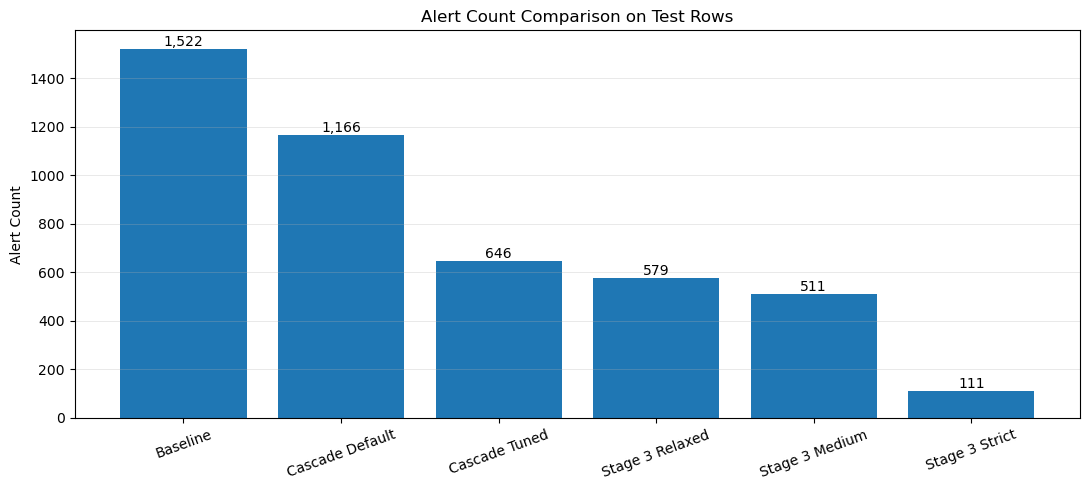

In [79]:
# Funnel Filter Chart 

model_comparison_summary = load_json(MODEL_COMPARISON_SUMMARY_PATH)

stages = [
    "Baseline",
    "Cascade Default",
    "Cascade Tuned",
    "Stage 3 Relaxed",
    "Stage 3 Medium",
    "Stage 3 Strict",
]

counts = [
    model_comparison_summary["baseline_alert_count_test_rows"],
    model_comparison_summary["cascade_default_alert_count_test_rows"],
    model_comparison_summary["cascade_tuned_alert_count_test_rows"],
    model_comparison_summary["stage3_relaxed_alert_count_test_rows"],
    model_comparison_summary["stage3_medium_alert_count_test_rows"],
    model_comparison_summary["stage3_strict_alert_count_test_rows"],
]

fig, ax = plt.subplots(figsize=(11, 5))
bars = ax.bar(stages, counts)

ax.set_title("Alert Count Comparison on Test Rows")
ax.set_ylabel("Alert Count")
ax.grid(axis="y", linestyle="-", linewidth=0.5, alpha=0.4)

for bar in bars:
    ax.text(
        bar.get_x() + bar.get_width() / 2,
        bar.get_height(),
        f"{int(bar.get_height()):,}",
        ha="center",
        va="bottom",
    )

plt.xticks(rotation=20)
plt.tight_layout()

comparison_alert_plot_path = GOLD_ARTIFACTS_PATH / f"{DATASET_NAME}__gold__alert_count_comparison_test_rows.png"
plt.savefig(comparison_alert_plot_path, dpi=200)
plt.show()


### Ask

What is this funnel chart helping me explain about the cascade?

### Answer

It helps me explain **where** the filtering pressure is happening.

If most of the alert drop happens between Stage 1 and Stage 2, then Stage 2 is acting as the main narrowing filter. If there is another large drop after that, then Stage 3 is doing most of the final cleanup. If the final stage barely changes the count, then Stage 3 may be too weak or mostly acting as a light confirmation layer.

So this chart helps me move from "the cascade changed the final count" to "this is the stage where the change actually happened."

----


Next Steps:

How could we improve our results with the highest ROI first? 

Tune our thresholds as decision variables, do not just use a “percentiles” threshold. 
    Performance is dominated currently the chosen thresholds for 
    - Stage 1 score → flag
    - Stage 2 score → flag
    - Stage 3 evidence → final flag

    So one method we can attempt to improve the score would be to switch away from a fixed percentiles to something like a simple grid search. 

    Using Grid Search, we would want to perform the search over the following items:
    - stage1_threshold_percentile (or absolute threshold)
    - stage2_threshold_percentile
    - min_rule_evidence (stage 3)
    - persistence_window / min_consecutive_points

    Objective Options:
    - Max F1 (Which is what we are already doing)
    - Max precision subject to recall greater than or eaqual to X, this is very defensible operationally.
    - Min alerts subject to recall greater than or equal to X

    These alone are often more likely to help improve our model's precision/f1 more than tuning the hyperparameters. 


Isolation Forest Hyperparameter Tuning:

If we do move to hyperparameter tuning, we should prioritize these:
- contamination: huge impact on alert volume. Even if you still threshold via score percentile, contamination affects tree structure and score distribution.
- n_estimators: stability of scores (more trees = smoother).
- max_samples: controls variance; can reduce noisy boundaries.
- max_features: can help when many sensors are irrelevant at a given time.
- bootstrap: sometimes stabilizes scoring.

If we have to choose only hyperparameter, it should be contamination but it should be paired with thresholding tuning as well. 



If we encounter a “Precision Ceiling”, then we should fix it with event-aware evaluation. 

Which is likely since we only have ~7 failure events across the year, row-level labeling is brutally imbalanced, without the use of a synthetic data generator. 

Then the two areas of improvements that often can raise our measured precision and better match real monitoring are:
- Event-window labeling: treat a detection as TP if it happens within a window before/after the event onset (e.g., ±N steps).
- Alert de-duplication: collapse consecutive flagged rows into one “incident.” (Precision becomes “% of incidents that correspond to real events” instead of “% of rows.”)

This may feel like cheating, but it's actually more closely align to realistic operation procedure. 




# Future Improvements:


Stage 3 Changes:

Stage 3 is very weak, it is too weak and needs to be more discriminative or to act earlier like a gating mechanism. 

Upgrade Options:
1) Add hysteresis + Cooldown:
    This will reduce false positives without destroying our recall.  It does this by not flagging every row that meets evidence but instead by:
    - requiring a higher threshold to enter.
    - lowering the exit threshold 
    - adding a cool down so noisy fluctuations do not generate repeated alerts.

This ulimately cuts spams and increases perceived precision 

2) Make stage 3's evidence be weighted instead of counted:
    Right now we are simply adding profile breaches to corroboration to persistence to get our evidence count. 
    Instead we should add a weight multiplier to each item and only alert if the evidence score is over a threshold amount, like so:
        evidence_score = weight_1 * persistence + weight_2 * profile_breach + weight_3 * subsystem_corroboration + weight_4 * drift
        if evidence_score greather than or equal to threshold, then alert. 

This makes the decision boundaires tunable which tends to help improve the F1 score. 
     
3) Subsystem Corrobration Rules (this wone will have the best realism feel to it)
    - Here we would need to implement the subsystem grouping and fault propration. 
        - Example: If sensor 1 breaches, expect to see sensor B and/or sensor C to move within K steps.
        - Require something like a 2 of N sensors in the same subsystem to corroborate the anomaly occurance before alert. 

4) Replace our persistent detection with shape detection. 
    Currently we are only looking for steady noise but by changing it we are looking for degradtion not just that it stayed weird/noisy. 
        With this we would use something like a slopve/curvature features over a short window checking for:
            - rolling mean delta
            - rolling z-score change
            - monotonic trend check



       
Extra Stages:

If we were to add a fourth stage, then that stage should do something like Incident clustering with top contributors. 

Doing Incident clustering + top contributors means that we will cluster our alert windows into incidents, then compute “top sensors driving anomaly”, something like a simple: z-score magnitude or feature contribution proxy, and finally we would output the incident summary (start, peak, sensors involve). This won't change precision directly, but it makes our system look far more production-ready and helps really cover all grounds. 



Stage3 Redesign:
- Weighted evidence score
- Subsystem corroboration (2-of-N sensors in same subsystem)
- Hysteresis + cooldown (enter/exit thresholds, plus incident suppression)
- Incident de-dup metrics (incident-level precision/recall/F1 using your truth events)



----

## Run Final Lineage and Consistency Checks

Before I treat the comparison notebook as complete, I run a final sanity check on the saved comparison dataframe and truth artifacts.

This check verifies things like:
- required lineage columns exist in the comparison dataframe
- the dataframe truth hash matches the saved comparison truth
- the parent truth hash matches the shared Gold parent truth
- the saved truth file exists
- the saved comparison summary points back to the correct comparison truth hash
- the saved summary still references the correct baseline and cascade truth hashes

I like ending with this because it confirms that the comparison output is not only saved, but also internally consistent and traceable.

In [80]:
required_comparison_meta_columns = [
    "meta__truth_hash",
    "meta__parent_truth_hash",
    "meta__pipeline_mode",
]

missing_comparison_meta_columns = [
    column_name
    for column_name in required_comparison_meta_columns
    if column_name not in comparison_df.columns
]
if missing_comparison_meta_columns:
    raise ValueError(
        f"comparison_df is missing required lineage columns: {missing_comparison_meta_columns}"
    )

comparison_df_truth_hash_check = extract_truth_hash(comparison_df)

if comparison_df_truth_hash_check is None:
    raise ValueError("comparison_df does not contain a readable meta__truth_hash value.")

if comparison_df_truth_hash_check != COMPARISON_TRUTH_HASH:
    raise ValueError(
        "comparison_df truth hash does not match COMPARISON_TRUTH_HASH:\n"
        f"dataframe={comparison_df_truth_hash_check}\n"
        f"record={COMPARISON_TRUTH_HASH}"
    )

comparison_parent_values = comparison_df["meta__parent_truth_hash"].dropna().astype(str).unique().tolist()

if not comparison_parent_values:
    raise ValueError("comparison_df is missing populated meta__parent_truth_hash values.")

if len(comparison_parent_values) != 1:
    raise ValueError(f"comparison_df has multiple parent truth hashes: {comparison_parent_values}")

if comparison_parent_values[0] != GOLD_PARENT_TRUTH_HASH:
    raise ValueError(
        "comparison_df parent truth hash does not match GOLD_PARENT_TRUTH_HASH:\n"
        f"dataframe_parent={comparison_parent_values[0]}\n"
        f"gold_parent={GOLD_PARENT_TRUTH_HASH}"
    )

if not Path(comparison_truth_path).exists():
    raise FileNotFoundError(f"Comparison truth file was not created: {comparison_truth_path}")

loaded_comparison_truth = load_json(comparison_truth_path)

if loaded_comparison_truth.get("truth_hash") != COMPARISON_TRUTH_HASH:
    raise ValueError(
        "Saved Comparison truth file hash does not match COMPARISON_TRUTH_HASH:\n"
        f"file={loaded_comparison_truth.get('truth_hash')}\n"
        f"record={COMPARISON_TRUTH_HASH}"
    )

if loaded_comparison_truth.get("parent_truth_hash") != GOLD_PARENT_TRUTH_HASH:
    raise ValueError(
        "Saved Comparison truth file parent hash does not match GOLD_PARENT_TRUTH_HASH:\n"
        f"truth={loaded_comparison_truth.get('parent_truth_hash')}\n"
        f"gold_parent={GOLD_PARENT_TRUTH_HASH}"
    )

saved_comparison_summary = load_json(MODEL_COMPARISON_SUMMARY_PATH)

if saved_comparison_summary.get("baseline_truth_hash") != BASELINE_TRUTH_HASH:
    raise ValueError(
        "comparison_summary baseline_truth_hash does not match BASELINE_TRUTH_HASH:\n"
        f"summary={saved_comparison_summary.get('baseline_truth_hash')}\n"
        f"baseline={BASELINE_TRUTH_HASH}"
    )

if saved_comparison_summary.get("cascade_default_truth_hash") != CASCADE_DEFAULTS_TRUTH_HASH:
    raise ValueError(
        "comparison_summary cascade_default_truth_hash does not match CASCADE_DEFAULTS_TRUTH_HASH:\n"
        f"summary={saved_comparison_summary.get('cascade_default_truth_hash')}\n"
        f"default={CASCADE_DEFAULTS_TRUTH_HASH}"
    )

if saved_comparison_summary.get("cascade_tuned_truth_hash") != CASCADE_TUNED_TRUTH_HASH:
    raise ValueError(
        "comparison_summary cascade_tuned_truth_hash does not match CASCADE_TUNED_TRUTH_HASH:\n"
        f"summary={saved_comparison_summary.get('cascade_tuned_truth_hash')}\n"
        f"tuned={CASCADE_TUNED_TRUTH_HASH}"
    )

if saved_comparison_summary.get("cascade_stage3_improved_truth_hash") != CASCADE_STAGE3_IMPROVED_TRUTH_HASH:
    raise ValueError(
        "comparison_summary cascade_stage3_improved_truth_hash does not match CASCADE_STAGE3_TRUTH_HASH:\n"
        f"summary={saved_comparison_summary.get('cascade_stage3_improved_truth_hash')}\n"
        f"stage3={CASCADE_STAGE3_IMPROVED_TRUTH_HASH}"
    )

if saved_comparison_summary.get("gold_truth_hash") != GOLD_PARENT_TRUTH_HASH:
    raise ValueError(
        "comparison_summary gold_truth_hash does not match GOLD_PARENT_TRUTH_HASH:\n"
        f"summary={saved_comparison_summary.get('gold_truth_hash')}\n"
        f"gold={GOLD_PARENT_TRUTH_HASH}"
    )


print("Gold Comparison lineage sanity check passed.")

2026-03-24 23:01:36,074 | INFO | capstone.file_io | Loading JSON: /workspace/artifacts/truths/gold_comparison/pump__gold_comparison__truth__7795dd76cf825f5f48ea95b8dc59f50b1cf1dbe8e511e333d2c6cb4a88af8e2f.json


2026-03-24 23:01:36,092 | INFO | capstone.file_io | Loading JSON: /workspace/artifacts/gold/pump/pump__gold__model_comparison_summary.json


Gold Comparison lineage sanity check passed.


### Ask

What does this final sanity check really confirm?

### Answer

It confirms that the comparison results can be trusted as a pipeline artifact, not just as notebook output.

A comparison notebook can run successfully and still leave behind mismatched truth hashes, broken lineage, or saved summaries that no longer line up with the dataframe they are supposed to describe. This final check helps guard against that.

So this is really a trust check more than a completion check.

----

## Optional PostgreSQL Write for Comparison Outputs

This section is for writing the comparison summary into PostgreSQL.

I am treating this as an optional persistence step rather than part of the core comparison deliverable. The main outputs from this notebook are still the saved comparison CSV, comparison summary JSON, comparison plot, funnel chart, ledger, and truth record. Writing to SQL is useful when I want the comparison artifact available for querying, validation, or downstream integration work.

SQL_SCHEMAS = {
    "bronze": "bronze",
    "silver": "silver",
    "gold": "gold",
    "synthetic": "synthetic",
    "truth": "truth",
    "audit": "audit",
}

GOLD_ARTIFACT_TABLES = {
    "baseline_results": "baseline_results",
    "baseline_summary": "baseline_summary",
    "baseline_thresholds": "baseline_thresholds",
    "cascade_results": "cascade_results",
    "cascade_summary": "cascade_summary",
    "cascade_thresholds": "cascade_thresholds",
    "comparison_summary": "comparison_summary",
}

SYNTHETIC_ARTIFACT_TABLES = {
    "batch": "batch",
    "stream": "stream",
    "sensor_messages": "sensor_messages",
}




GOLD_SCHEMA = SQL_SCHEMAS["gold"]

engine = get_engine_from_env()

comparison_summary_df = pd.DataFrame([comparison_summary])

gold_comparison_results_sql = prepare_layer_dataframe(
    comparison_summary_df,
    truth_hash=COMPARISON_TRUTH_HASH,
    parent_truth_hash=GOLD_PARENT_TRUTH_HASH,
    pipeline_mode=PIPELINE_MODE,
    process_run_id=GOLD_PROCESS_RUN_ID,
    add_loaded_at_column=True,
)

comparison_summary_results_table = write_layer_dataframe(
    engine=engine,
    dataframe=gold_comparison_results_sql,
    schema=GOLD_SCHEMA,
    dataset_name=DATASET_NAME,
    artifact_name=GOLD_ARTIFACT_TABLES["comparison_summary"],
    if_exists="replace",
    index=False,
)

print(f"Wrote table: {GOLD_SCHEMA}.{comparison_summary_results_table}")

----

First setup created:

Alerts
- Tuned: 646
- Stage3 Relaxed: 648
- Stage3 Medium: 646
- Stage3 Strict: 579

Interpretation:
- Relaxed + Medium = doing nothing meaningful
- Strict = over-filtering hard


Stage 3 thresholds are still too weak or all stage 2 covered all conditions. 

Lets try changing some of the conditions for our medium and relaxed stages to make them more strict and meaningful and loosen the strict settings as it is way to aggressive. 

stage3_medium_flag will be changed to an AND condition instead of OR. Currently, the flag is set to true if  rule_evidence_count of equal to 2 or greater than 2 OR stage3_confirmed_flag. Now it will be if stage2_flag is equal to 1 AND stage3_weighted_evidence_score is equal to 2 or greater than 2. 

stage3_relaxed_flag will be changed to an AND condition instead of OR. Currenty, the flag is set to be true if profile breach is true or corroboration is set to true. Now it will be set to if stage2_flag is equal to 1 AND stage3_weighted_evidence_score is equal to 2 or greater than 1. 

stage3_strict flag will be changed from a single condition to an AND condition. Currently the flag is set to true if strong_primary_only is set to true. Now it will be set to if stage2_flag is equal to 1 AND stage3_weighted_evidence_score is equal to 2 or greater than 3. 


Stage 3 enables configurable filtering levels that allow the system to trade off between recall and alert reduction depending on operational needs.

----

Second Adjustments:

Alerts: 
- Tuned: 646
- Stage3 Relaxed: 648
- Stage3 Medium: 646 
- Stage3 Strict: 579

Interpretation:

----


From your metrics:

Tuned
Precision: ~0.093
Recall: ~0.508
F1: ~0.157
Stage 3 Relaxed
Precision: ↑ (0.098)
Recall: slightly ↓
F1: ↑ (0.163)

    This is actually the best balanced model now

Stage 3 Medium
Precision drops
Recall drops a lot
F1 worse
    This is my weakest variant (likely over-filtering unevenly)

Stage 3 Strict
Precision: 0.234 (very high)
Recall: low (~0.22)
F1: 0.227 (highest overall)
    This is my high-precision operating mode


1. Tuned Cascade (baseline production)
- Best recall balance
- Good precision
- Stable

2. Stage 3 Relaxed (recommended upgrade)
- Slightly better precision
- Slightly better F1
- Minimal alert loss
    This is arguably my best overall model

3. Stage 3 Strict (high-confidence mode)
- Much higher precision
- Lower recall
- Highest F1

    Use when:
        - false positives are expensive
        - human review is limited

Stage 3 does not need to replace the Stage 2, it needs to enhance it by enabling multiple operating thresholds depending on business constraints.